In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

experiments_objects = [JAL6_flip3_18mar]

In [ ]:
%load_ext autoreload
%autoreload 2
from settings.settings_analyze_efizz import Settings_ae as settings
from behave_analysis.process.process import Process
from behave_analysis.analyze.analyze_efizz import AnalyzeEfizz
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from behave_analysis.analyze.EscapePattern.ComputeEscapeTuning import ComputeEscapeTuning

import os
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
"""This cell can be deleted, just needed to make some quick lab meeting plots"""
# from behave_analysis.analyze.AnalyzeBehave import AnalyzeBehave
# from settings.settings_analyze_behave import Settings

# e = experiments_objects[0]
# session = Process(e).load_session()

# abehave = AnalyzeBehave(session, Settings)
# abehave.load_data('correlations')
# abehave.behaviour_analyses('correlations', ['speed', 'bird_dist_shelter', 'distance_shelter', 'escape', 'hdir'])

2026-03-12 14:54:05.838 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 14:54:05.846 | INFO     | behave_analysis.analyze.AnalyzeBehave:__init__:30 - Initializing AnalyzeBehave
2026-03-12 14:54:15.227 | INFO     | behave_analysis.utils.data_loading:load_or_extract_escapes:66 - Escape object found. Loading...
2026-03-12 14:54:15.235 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:33 - Homings object found. Loading...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 5) + inhomogeneous part.

In [25]:
step = [20, 80, 200, 400, 800]
e = experiments_objects[0]
analysis_name = 'EscapePattern'
variable = "escape in homing&escape"
session = Process(e).load_session()
data_path = os.path.join(session.base_path, session.processed_path, "models", "escape_tuning")
settings_to_check(settings, ["linshift", "ep_"])
fraction_sig_condition = np.zeros((len(step), 3))
for s in step:
    settings = settings_overrides(settings, {'redo_compute': False,                  
                                            'linshift_min_step': s,
                                            'linshift_step': s})
    _, do_analysis, hexaname = check_database_for_same_run(
                                    db_settings={"variable": variable, **(settings_to_check(settings, ["linshift", "ep_"]))},
                                    results_csv_name=data_path + os.sep + "EscapePattern_results.csv",
                                    settings=settings,
                                )
    print("Hexaname found in database: {}, do_analysis: {}".format(hexaname, do_analysis))
    if do_analysis:
        aefizz = AnalyzeEfizz(session, settings)
        aefizz.load_data(analysis_name)
        computeET = ComputeEscapeTuning(variable, aefizz)
        computeET.prepare_data()
        computeET.filter_data_and_compute_tuning()
        computeET.compute_statistical_significance()
        data = computeET.save_escape_tuning(variable, return_dict=True)
    else:
        data = np.load(os.path.join(data_path, "EPtuning_" + hexaname + "_results.npz"), allow_pickle=True)
    
    
    shift0 = int(np.shape(data['y_fitted_shift'])[0] / 2)
    peak_to_mean_real = np.divide(data['params_shifts'][shift0, :, :, 0], 
                                    (np.nanmean(data['y_fitted_full'], axis=2)).T,
                                    out=np.zeros_like(data['params_shifts'][shift0, :, :, 0], dtype=np.float64),
                                    where=(np.nanmean(data['y_fitted_full'], axis=2)).T!=0)
    peak_to_mean_shift = np.divide(data['params_shifts'][:, :, :, 0],
                                    (np.nanmean(data['y_fitted_shift'], axis=3).transpose(0,2,1)),
                                    out=np.zeros_like(data['params_shifts'][:, :, :, 0], dtype=np.float64),
                                    where=(np.nanmean(data['y_fitted_shift'], axis=3).transpose(0,2,1))!=0)
    # sig_escape = data['params_shifts'][shift0, :, :, 0] > np.nanpercentile(data['params_shifts'][:, :, :, 0], 95, axis=0)
    sig_escape = peak_to_mean_real > np.nanpercentile(peak_to_mean_shift, 95, axis=0)
    fraction_sig_condition[step.index(s), :] = np.sum(sig_escape, axis = 0) / np.repeat(sig_escape.shape[0], 3)

2026-03-10 15:17:42.539 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-10 15:17:42.591 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['3321b7287c46482d'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\escape_tuning\EscapePattern_results.csv


Hexaname found in database: 3321b7287c46482d, do_analysis: False


2026-03-10 15:17:44.464 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['b3fd402bc7b84047'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\escape_tuning\EscapePattern_results.csv


Hexaname found in database: b3fd402bc7b84047, do_analysis: False


2026-03-10 15:17:45.933 | INFO     | behave_analysis.analyze.analyze_efizz:__init__:58 - Initializing AnalyzeEfizz


...

2026-03-10 15:19:01.720 | WARNING  | behave_analysis.analyze.EscapePattern.escape_pattern_utils:select_onset_offsets_in_shift_vector:151 - Debug this function to make sure it is working correctly!
2026-03-10 15:38:08.194 | INFO     | behave_analysis.analyze.results_database_utils:add_run_to_database:145 - Added run 34b38f8c3c0e42fb to database
2026-03-10 15:38:08.455 | INFO     | behave_analysis.analyze.analyze_efizz:__init__:58 - Initializing AnalyzeEfizz


Hexaname found in database: 64468e2cf5854bcd, do_analysis: True


2026-03-10 15:39:24.931 | WARNING  | behave_analysis.analyze.EscapePattern.escape_pattern_utils:select_onset_offsets_in_shift_vector:151 - Debug this function to make sure it is working correctly!
2026-03-10 15:56:56.875 | INFO     | behave_analysis.analyze.results_database_utils:add_run_to_database:145 - Added run 717ba3b0b2174ab1 to database
2026-03-10 15:56:57.266 | INFO     | behave_analysis.analyze.analyze_efizz:__init__:58 - Initializing AnalyzeEfizz


Hexaname found in database: ba813694db104794, do_analysis: True


2026-03-10 15:58:27.237 | WARNING  | behave_analysis.analyze.EscapePattern.escape_pattern_utils:select_onset_offsets_in_shift_vector:151 - Debug this function to make sure it is working correctly!
2026-03-10 16:15:04.362 | INFO     | behave_analysis.analyze.results_database_utils:add_run_to_database:145 - Added run 2e172a4b775444bc to database


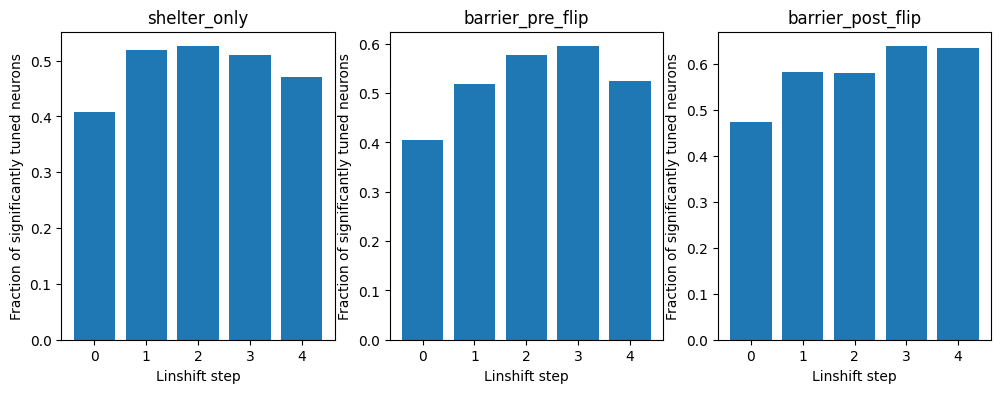

In [32]:
%matplotlib inline
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

conditions = ['shelter_only', 'barrier_pre_flip', 'barrier_post_flip']

for c in range(3):
    axs[c].bar(np.arange(len(step)), fraction_sig_condition[:, c])
    axs[c].set_xlabel('Linshift step')
    axs[c].set_ylabel('Fraction of significantly tuned neurons')
    axs[c].set_title(conditions[c])